# Tasks

In [2]:
# imports 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [3]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

100.0%
100.0%
100.0%
100.0%


# Task 1

In [4]:
# 3. MODEL DEFINITION


class FashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),

            # Layer 1
            nn.Linear(28*28, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Output layer
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.model(x)


model = FashionClassifier().to(device)
print(model)


FashionClassifier(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=256, out_features=128, bias=True)
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [5]:
# LOSS, OPTIMIZER, SCHEDULER

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

epochs = 15

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)


In [6]:
# 5. TRAINING LOOP

train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0
best_epoch = 0


def accuracy(preds, labels):
    _, predicted = torch.max(preds, 1)
    return (predicted == labels).sum().item() / labels.size(0)


for epoch in range(epochs):
# TRAINING PHASE
    
    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        # 1. zero gradients
        optimizer.zero_grad()

        # 2. forward pass
        outputs = model(x)

        # 3. loss
        loss = criterion(outputs, y)

        # 4. backward pass
        loss.backward()

        # 5. update weights
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == y).sum().item()
        train_total += y.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # VALIDATION PHASE
    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)

            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == y).sum().item()
            val_total += y.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total


    # scheduler step
    scheduler.step()

    # save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # best model tracking
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, "
          f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

Epoch [1/15] Train Loss: 0.5879, Val Loss: 0.4010, Train Acc: 0.8114, Val Acc: 0.8523
Epoch [2/15] Train Loss: 0.4040, Val Loss: 0.3606, Train Acc: 0.8540, Val Acc: 0.8685
Epoch [3/15] Train Loss: 0.3688, Val Loss: 0.3612, Train Acc: 0.8673, Val Acc: 0.8689
Epoch [4/15] Train Loss: 0.3445, Val Loss: 0.3490, Train Acc: 0.8749, Val Acc: 0.8722
Epoch [5/15] Train Loss: 0.3246, Val Loss: 0.3258, Train Acc: 0.8814, Val Acc: 0.8806
Epoch [6/15] Train Loss: 0.3089, Val Loss: 0.3362, Train Acc: 0.8865, Val Acc: 0.8774
Epoch [7/15] Train Loss: 0.3013, Val Loss: 0.3119, Train Acc: 0.8909, Val Acc: 0.8863
Epoch [8/15] Train Loss: 0.2855, Val Loss: 0.3129, Train Acc: 0.8943, Val Acc: 0.8860
Epoch [9/15] Train Loss: 0.2676, Val Loss: 0.2966, Train Acc: 0.9017, Val Acc: 0.8919
Epoch [10/15] Train Loss: 0.2568, Val Loss: 0.2970, Train Acc: 0.9062, Val Acc: 0.8936
Epoch [11/15] Train Loss: 0.2451, Val Loss: 0.2943, Train Acc: 0.9098, Val Acc: 0.8920
Epoch [12/15] Train Loss: 0.2324, Val Loss: 0.2906, 

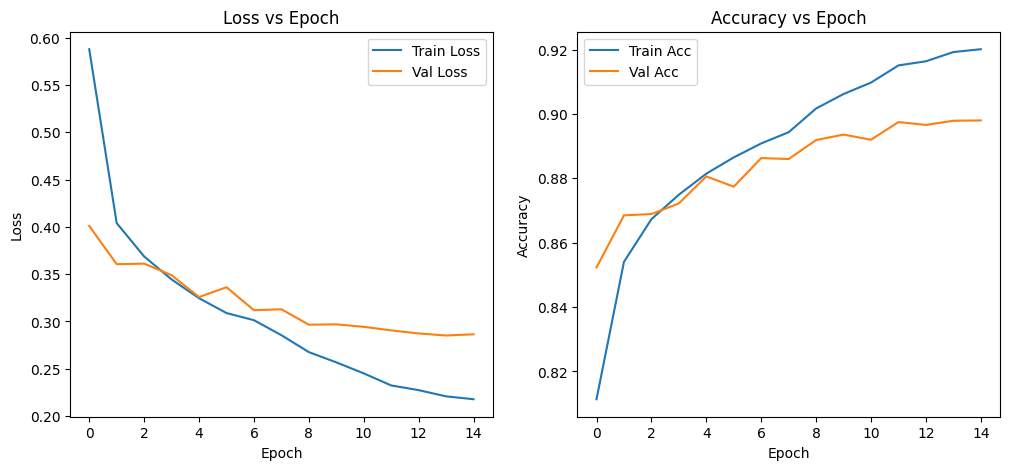

In [7]:
# RESULTS PLOTTING

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()



In [8]:
# BEST RESULT

print("Best Validation Accuracy:", best_val_acc)
print("Best Epoch:", best_epoch)

Best Validation Accuracy: 0.898
Best Epoch: 15


# In a short markdown cell (2–3 sentences), describe what your curves look like — for example, does the model still improve at epoch 15, do training and validation loss stay close together, and what is your best validation accuracy. Validation accuracy is expected to land around 89–90% on this architecture; report whatever number you actually got.

The model demonstrates strong and consistent improvement throughout all 15 epochs, with training loss decreasing from 0.5879 to 0.2178 and validation loss from 0.4010 to 0.2864, indicating good convergence without significant overfitting. The training and validation loss curves track closely together, suggesting effective regularization through batch normalization and dropout. The model achieves its best validation accuracy of 89.8% at epoch 15, hitting the expected performance range and continuing to improve even on the final epoch.